First Initial Script for understanding the data drill down in details and get the insights

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Reading the dataset : 
df  = pd.read_csv("../data/supply_chain_dataset.csv")

In [5]:
df.head()

,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
0,2024-01-01,SKU_1,WH_1,SUP_8,West,10,592,14,379,0,13.95,20.48,0,0,8.52
1,2024-01-02,SKU_1,WH_1,SUP_8,West,17,575,14,379,0,13.95,20.48,0,0,18.63
2,2024-01-03,SKU_1,WH_1,SUP_8,North,35,540,14,379,0,13.95,20.48,1,0,39.62
3,2024-01-04,SKU_1,WH_1,SUP_8,South,24,516,14,379,0,13.95,20.48,0,0,19.43
4,2024-01-05,SKU_1,WH_1,SUP_8,West,21,495,14,379,0,13.95,20.48,0,0,18.70


Lets check some basic analytics like info , description , shape size ,  describe . etc

In [6]:
df.tail()

,Date,SKU_ID,Warehouse_ID,Supplier_ID,Region,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
91245,2024-12-26,SKU_50,WH_5,SUP_10,South,17,352,7,283,0,6.65,9.6,0,0,19.82
91246,2024-12-27,SKU_50,WH_5,SUP_10,South,21,331,7,283,0,6.65,9.6,0,0,27.96
91247,2024-12-28,SKU_50,WH_5,SUP_10,East,17,314,7,283,0,6.65,9.6,0,0,22.13
91248,2024-12-29,SKU_50,WH_5,SUP_10,South,24,290,7,283,0,6.65,9.6,1,0,24.11
91249,2024-12-30,SKU_50,WH_5,SUP_10,West,15,275,7,283,0,6.65,9.6,1,0,20.19


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 91250 entries, 0 to 91249
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Date                     91250 non-null  object 
 1   SKU_ID                   91250 non-null  object 
 2   Warehouse_ID             91250 non-null  object 
 3   Supplier_ID              91250 non-null  object 
 4   Region                   91250 non-null  object 
 5   Units_Sold               91250 non-null  int64  
 6   Inventory_Level          91250 non-null  int64  
 7   Supplier_Lead_Time_Days  91250 non-null  int64  
 8   Reorder_Point            91250 non-null  int64  
 9   Order_Quantity           91250 non-null  int64  
 10  Unit_Cost                91250 non-null  float64
 11  Unit_Price               91250 non-null  float64
 12  Promotion_Flag           91250 non-null  int64  
 13  Stockout_Flag            91250 non-null  int64  
 14  Demand_Forecast       

In [8]:
df.describe()

,Units_Sold,Inventory_Level,Supplier_Lead_Time_Days,Reorder_Point,Order_Quantity,Unit_Cost,Unit_Price,Promotion_Flag,Stockout_Flag,Demand_Forecast
count,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.000000,91250.0,91250.000000
mean,20.054564,471.522312,7.984000,300.068000,19.272493,12.203320,18.261800,0.101589,0.0,20.082033
std,9.068602,133.488002,3.907929,54.879945,82.340831,4.574982,7.121136,0.302109,0.0,9.503955
min,0.000000,168.000000,2.000000,201.000000,0.000000,5.020000,6.950000,0.000000,0.0,0.000000
25%,13.000000,370.000000,4.000000,252.000000,0.000000,8.180000,12.000000,0.000000,0.0,12.950000
50%,20.000000,461.000000,8.000000,300.000000,0.000000,11.990000,18.180000,0.000000,0.0,19.950000
75%,27.000000,564.000000,11.000000,346.000000,0.000000,16.320000,23.390000,0.000000,0.0,26.930000
max,59.000000,990.000000,14.000000,398.000000,499.000000,19.760000,35.100000,1.000000,0.0,61.420000


In [9]:
df.shape

(91250, 15)

In [10]:
# Lets check for the null and Duplicate values in the dataser  : 

df.isnull().sum()

Date                       0
SKU_ID                     0
Warehouse_ID               0
Supplier_ID                0
Region                     0
Units_Sold                 0
Inventory_Level            0
Supplier_Lead_Time_Days    0
Reorder_Point              0
Order_Quantity             0
Unit_Cost                  0
Unit_Price                 0
Promotion_Flag             0
Stockout_Flag              0
Demand_Forecast            0
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

As we can see there is No null values Nor these are any duplicate values in the datadrame. 


### Lets start with the Univariate , Bivariate and Multivariate Analysis then

# Univariate Analysis

These are the columns in which I will do the univaraite analysis  : 
<br>                         
 4   Region                 
 5   Units_Sold              
 6   Inventory_Level          
 7   Supplier_Lead_Time_Days  
 8   Reorder_Point            
 9   Order_Quantity          
 10  Unit_Cost               
 11  Unit_Price               
 13  Stockout_Flag           
 14  Demand_Forecast

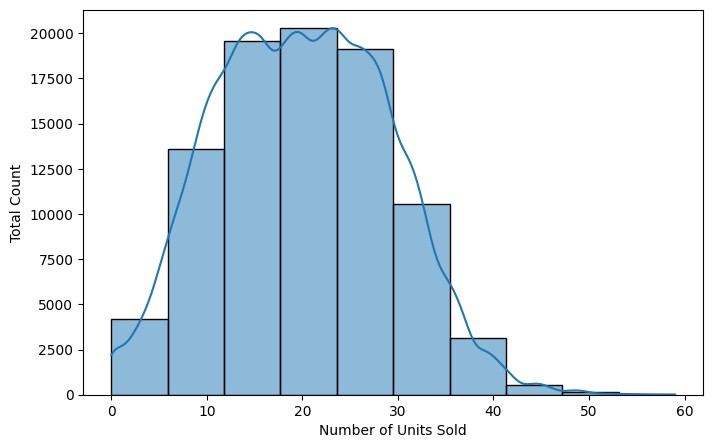

In [12]:
# Lets see the distribution of the units sold : 

plt.figure(figsize= (8 , 5))
sns.histplot(df['Units_Sold'] , kde=10 , bins=10)
plt.xlabel("Number of Units Sold")
plt.ylabel("Total Count")
plt.show()

As we can see that the Graph is the Positive Skew. Most of the Distributions in the Middle Range - Most of the items which are sold in teh range of 10 to max 30 and the high number of units are not sold in high count. 

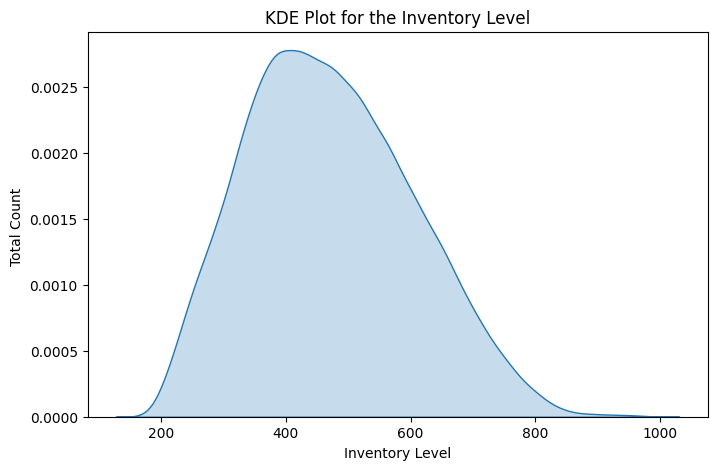

In [17]:
plt.figure(figsize  = (8 , 5))
plt.title("KDE Plot for the Inventory Level")
sns.kdeplot(df['Inventory_Level'], fill=True)
plt.xlabel("Inventory Level")
plt.ylabel("Total Count ")
plt.show()

As we can see from the inventory plot taht mos tof the inventory that is in stock is from the range of 200 - 800

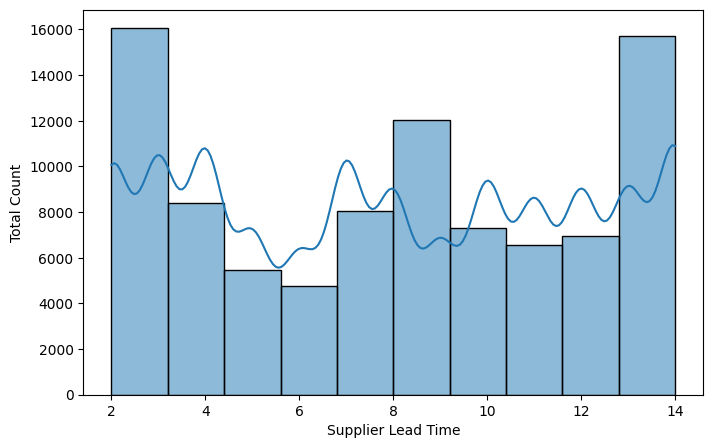

In [20]:
plt.figure(figsize= (8 , 5))
sns.histplot(df['Supplier_Lead_Time_Days'] , kde=10 , bins=10)
plt.xlabel("Supplier Lead Time")
plt.ylabel("Total Count")
plt.show()

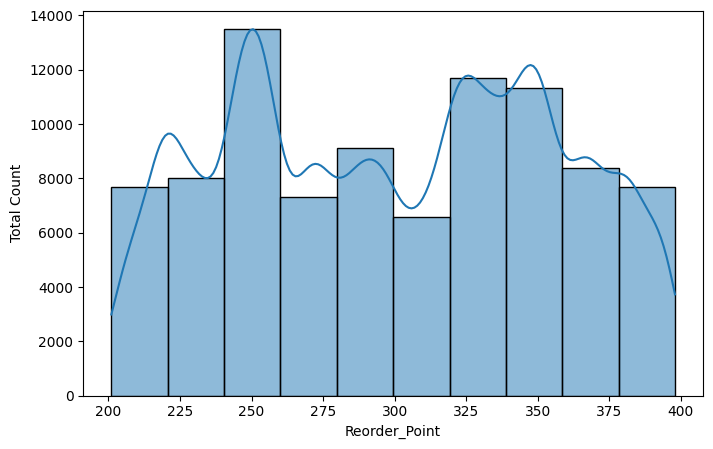

In [22]:
plt.figure(figsize= (8 , 5))
sns.histplot(df['Reorder_Point'] , kde=10 , bins=10)
plt.xlabel("Reorder_Point")
plt.ylabel("Total Count")
plt.show()

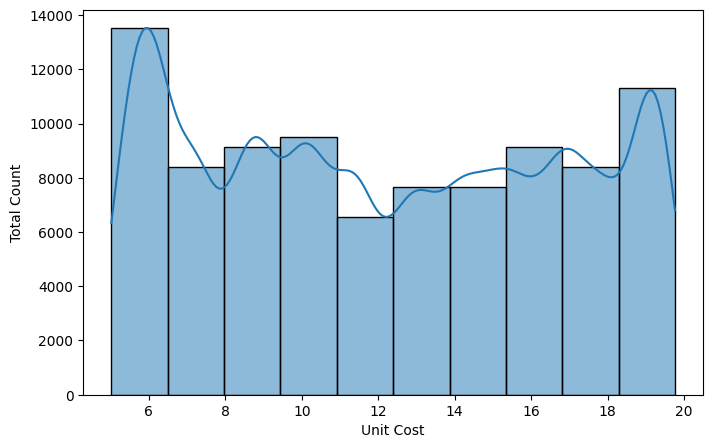

In [24]:
plt.figure(figsize= (8 , 5))
sns.histplot(df['Unit_Cost'] , kde=10 , bins=10)
plt.xlabel("Unit Cost")
plt.ylabel("Total Count")
plt.show()

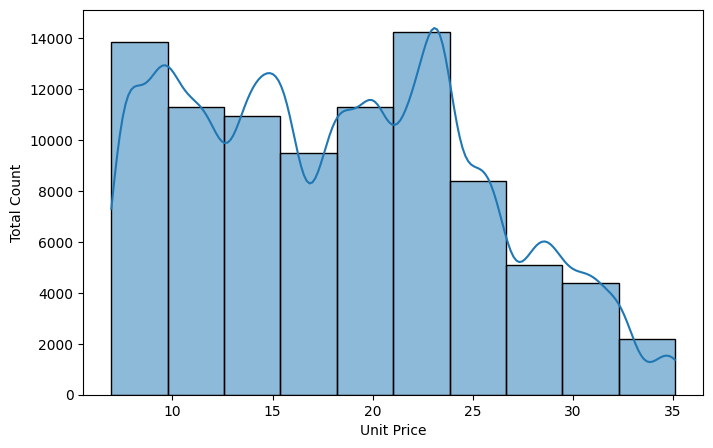

In [25]:
plt.figure(figsize= (8 , 5))
sns.histplot(df['Unit_Price'] , kde=10 , bins=10)
plt.xlabel("Unit Price")
plt.ylabel("Total Count")
plt.show()